In [2]:
import os
import math
import bayesflow as bf
import numpy as np  
import numba as nb
import keras
import matplotlib.pyplot as plt
from pathlib import Path


os.environ["KERAS_BACKEND"] = "tensorflow"

RNG = np.random.default_rng(2026)

### Simulate DMC trials
Parameters: 
* Drift rate controlled process ($\mu_c$)
* Amplitude automatic process: $A$
* Timepoint of max. automatic activation: $\tau$
* Boundary $b$
* Non-decision time $ndt$
* Condition cond: 0 = congruent, 1 = incongruent

In [ ]:
#@nb.jit(nopython = False, cache = True)
def mdmc_trial(muc, A, tau, b, ndts, noise, t, dt = 0.01): 
    # Simulate multiple DMC trials in parallel

    # Prepare output
    num_trials, _ = noise.shape
    rts = np.full(num_trials, -1.0)
    resps = np.full(num_trials, -1)

   # X0 = 0      # initial position for all trials, no starting point variability
    X0 = np.random.beta(3, 3, size=num_trials) * (2 * b) - b

    sigma = 4.0     # fixed sigma = 4 as in Ulrich2015
    sqrt_dt_sigma = sigma * np.sqrt(dt)

    mu_t = A / tau * np.exp(1 - t / tau) * (1 - t / tau) + muc
    dX = mu_t[None, :] * dt + sqrt_dt_sigma * noise  # shape (n_trials, T)

    X = np.cumsum(dX, axis=1)

    crossed_upper = X >= b
    crossed_lower = X <= -b
    crossed_any = crossed_upper | crossed_lower

    # First crossing index for each trial
    first_crossing = np.argmax(crossed_any, axis=1)
    has_crossed = np.any(crossed_any, axis=1)

    # Fill only for trials that crossed
    idx = np.where(has_crossed)[0]
    crossing_times = t[first_crossing[idx]]


    # use nondecision times only for trials that crossed
    ndts_crossed = ndts[idx]
    rts[idx] = (crossing_times + ndts_crossed) / 1000  # convert to seconds

    # Determine response type
    resp_hit = X[idx, first_crossing[idx]]
    resps[idx] = (resp_hit >= b).astype(int)

    return np.c_[rts, resps]

In [4]:
num_obs = 2
max_time = 15000
dt = 0.01

noise = np.random.normal(size = (num_obs, max_time))
ndts = np.random.normal(size = num_obs, loc=1, scale=1)
t = np.arange(1, noise.shape[1] + 1) * dt

obs_per_condition = int(np.ceil(num_obs / 4))
conditions = np.repeat(np.arange(4), obs_per_condition)

#noise = np.zeros((num_obs, max_time))
#ndts = np.zeros(num_obs)

mdmc_trial(muc=0.5, A=-20, tau=100, b=50, t=t, ndts=ndts, noise = noise)

array([[ 0.08955091,  1.        ],
       [-1.        , -1.        ]])

### Prior
as in amortized_dmc.pdf, Updated $sd_r$ fixed (rounded values)

In [5]:
def mdmc_prior(): 
    mu_r = RNG.normal(360, 25) 
    sd_r = RNG.normal(35, 8) 
    b = RNG.normal(60, 13)
    muc = RNG.normal(0.6, 0.15)
    A = RNG.normal(20, 8)
    tau = RNG.normal(120, 40)

    return dict(muc = muc, b = b, mu_r = mu_r, sd_r = sd_r, A = A, tau = tau)

In [6]:
mdmc_prior()

{'muc': 0.8093657565163042,
 'b': 35.34775745521215,
 'mu_r': 340.1719381210525,
 'sd_r': 36.9245702683062,
 'A': 25.106357927425723,
 'tau': 108.31810059122546}

### Number of Observations
Number of observations (trials) in each batch is randomly sampled.

In [7]:
# design matrix
min_obs = 50
max_obs = 100

def meta(batch_size, num_obs = None): 
    if num_obs == None:
        num_obs = np.random.randint(min_obs, max_obs)
#        num_obs = 100
    return dict(num_obs = num_obs)

### Observational Model (Experiment)

In [ ]:
def mdmc_experiment(num_obs, muc, A, tau, b, mu_r, sd_r): 
    max_time = 15000
    dt = 0.01

    # precompute time vector and noise
    noise = np.random.normal(size = (num_obs, max_time))
    ndts = np.random.normal(size = num_obs, loc=mu_r, scale=sd_r)
    t = np.arange(1, noise.shape[1] + 1) * dt

    out = np.zeros((num_obs, 2))        # to store rt and resp
 
    # congruency conditions (equal split)
    half = int(np.ceil(num_obs / 2)) + 1
    conditions = np.repeat(np.arange(2), half)[:num_obs]

    #print(len(conditions))
    # simulate CONG-CONG trials (A1 > 0, A2 > 0)
    out[:half] = mdmc_trial(
        muc=muc, A=A, tau=tau, b=b, t=t, ndts=ndts[:half], noise=noise[:half]
    )
    # simulate INCONG-CONG trials (A1 < 0, A2 < 0)
    out[half:] = mdmc_trial(
        muc=muc, A=-A, tau=tau, b=b, t=t, ndts=ndts[half:], noise=noise[half:]
    )
    
    return dict(rt = out[:, 0], resp = out[:, 1], conditions = conditions, num_obs = num_obs)
    

In [70]:
mdmc_experiment(num_obs = 65, muc = 0.5, A = 60, tau = 170, b = 50, mu_r = 300, sd_r = 36)

{'rt': array([ 0.35326587,  0.34577672,  0.38006711,  0.33751311,  0.43365493,
         0.35993564,  0.40381583,  0.25842717,  0.28649935, -1.        ,
         0.36087901,  0.34943664,  0.26503409,  0.29121261,  0.40224729,
         0.39612725,  0.34476799,  0.24288125,  0.3785389 ,  0.44119715,
         0.36695774,  0.28242887,  0.27615527,  0.31825529,  0.3266889 ,
         0.37445917,  0.36826442,  0.30912834,  0.33858701,  0.36716299,
         0.35867177,  0.34990088,  0.42946793,  0.30222952,  0.4079848 ,
        -1.        ,  0.44010486,  0.46736303,  0.39171045, -1.        ,
         0.38884248,  0.23952099,  0.37193556,  0.39142548, -1.        ,
         0.36371055,  0.32008634,  0.45322368,  0.32739833, -1.        ,
        -1.        ,  0.30262931,  0.41093899, -1.        ,  0.4707784 ,
         0.42637899,  0.42769381, -1.        ,  0.43056059,  0.30569761,
         0.39739469,  0.50148932,  0.32197694,  0.39096146, -1.        ]),
 'resp': array([ 1.,  1.,  1.,  1.,  1.,  1

In [71]:
simulator = bf.simulators.make_simulator([mdmc_prior, mdmc_experiment], meta_fn = meta)

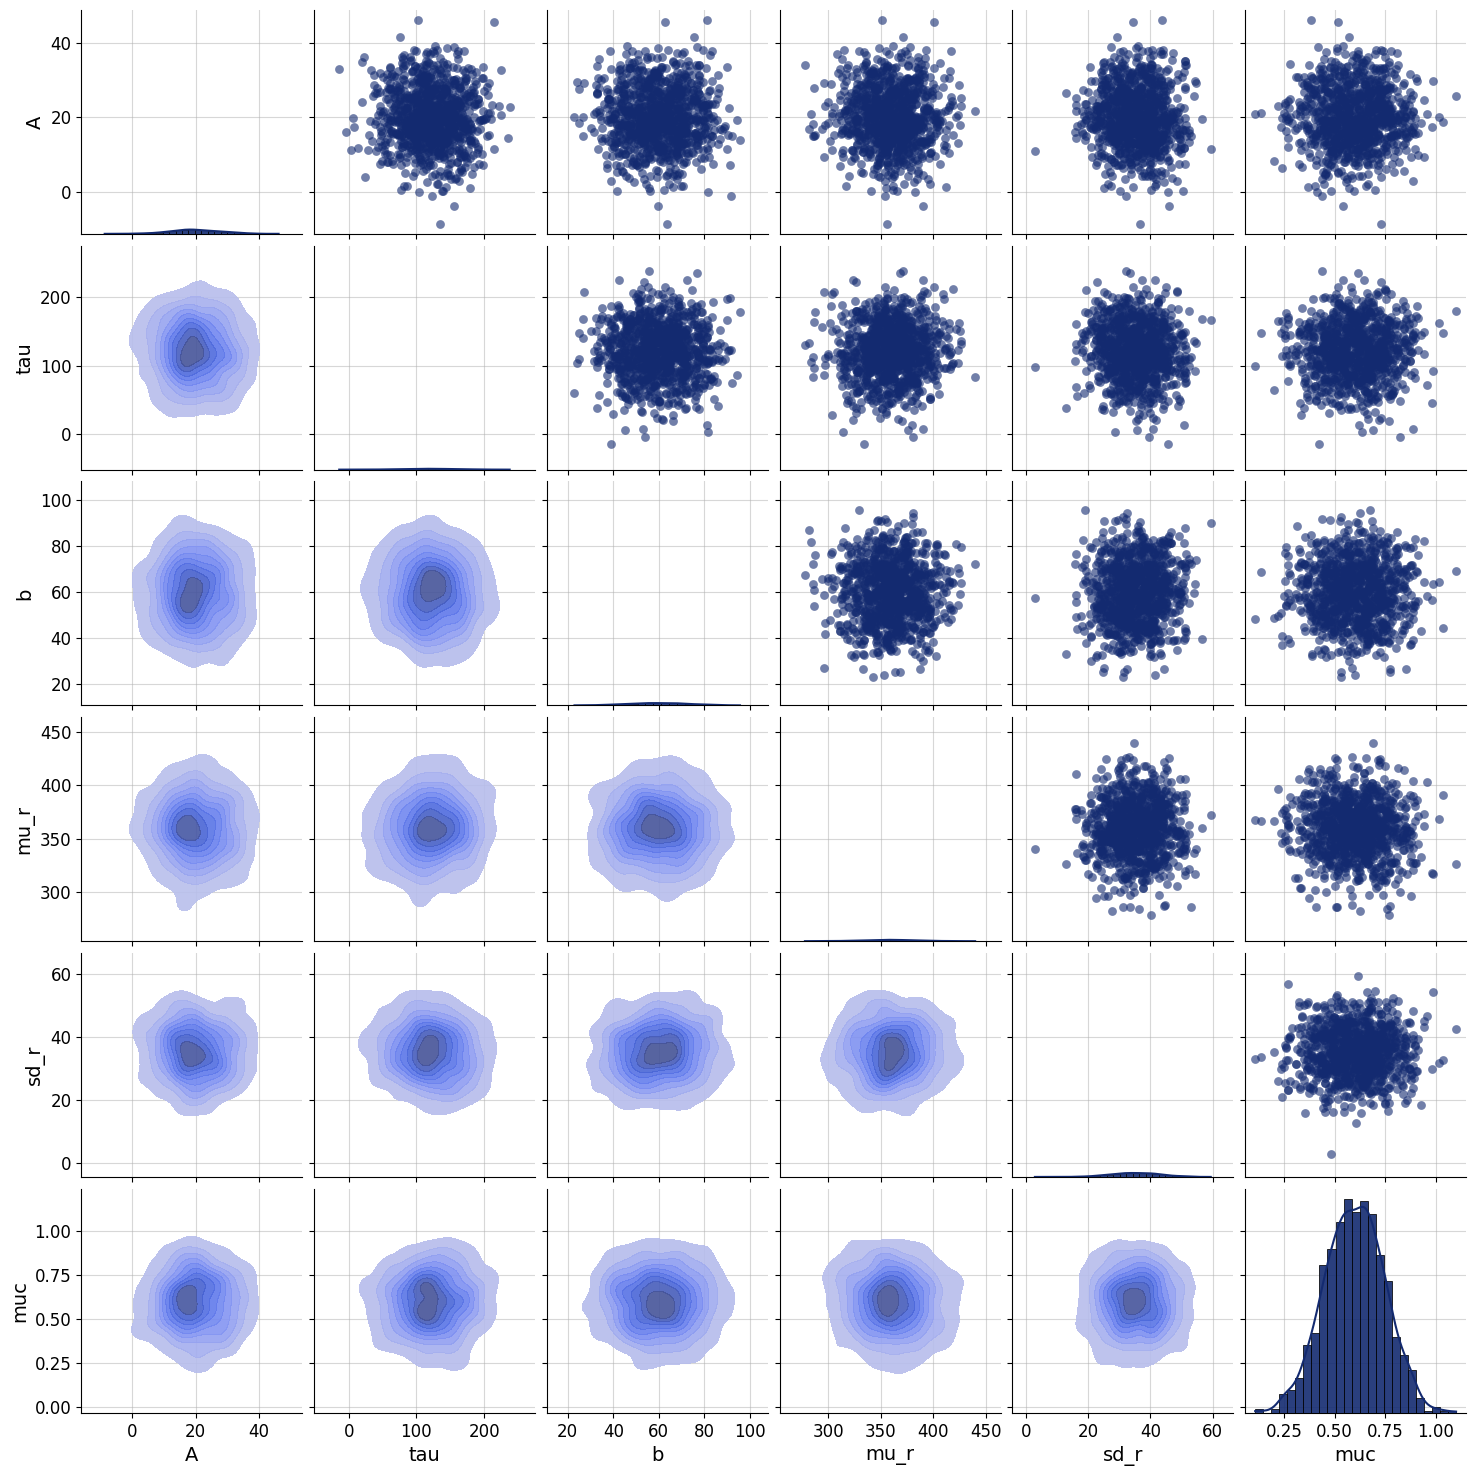

In [29]:
df = simulator.sample(1_000)

f = bf.diagnostics.pairs_samples(
    samples=df,
    variable_keys = ["A", "tau", "b", "mu_r", "sd_r", "muc"]
)

In [75]:
sim_data = simulator.sample(100)
#print("Number of observations:", sim_data["num_obs"])
print("Shape of rt:", sim_data["rt"].shape)
print("Shape of response:", sim_data["resp"].shape)
print("Shape of condition:", sim_data["conditions"].shape)

Shape of rt: (100, 61)
Shape of response: (100, 61)
Shape of condition: (100, 61)


In [20]:
adapter = (bf.Adapter()
    .as_set(["rt", "resp", "conditions"])
#    .constrain(["muc", "ndt"], lower=0)
    .concatenate(["muc", "A", "tau", "mu_r", "sd_r", "b"], into = "inference_variables")
    .concatenate(["rt", "resp", "conditions"], into = "summary_variables")
    .rename("num_obs", "inference_conditions")
)

In [ ]:
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    initial_learning_rate=5e-4,
    inference_network=bf.networks.FlowMatching(
        dropout=0.0107
    ),
    summary_network=bf.networks.SetTransformer(
        dropout=0.0107,
        learning_rate = 0.00057
#        num_seeds=7,
#        summary_dim=22,
#        embed_dims=(128, 128)
    ),
    inference_variables = ["muc", "A", "tau", "mu_r", "sd_r", "b"],
    inference_conditions = ["num_obs"], 
    summary_variables = ["rt", "resp", "conditions"],
    checkpoint_filepath = Path(os.getcwd()).resolve(),  # save in cwd
    checkpoint_name = "DMC_1003_fitoff"                       # file name
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [60]:
train_data = simulator.sample(2_000)
validation_data = simulator.sample(500)

In [61]:
history = workflow.fit_offline(
    data=train_data,
    epochs=100, 
    batch_size=128,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - loss: 2635.2732 - val_loss: 235.2677
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 828ms/step - loss: 930.8475 - val_loss: 31.0253
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 830ms/step - loss: 400.7343 - val_loss: 28.6186
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 830ms/step - loss: 172.4815 - val_loss: 13.6515
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 835ms/step - loss: 90.9333 - val_loss: 19.7970
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 858ms/step - loss: 53.8342 - val_loss: 4.9103
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 836ms/step - loss: 34.6099 - val_loss: 6.4663
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 841ms/step - loss: 22.1659 - val_loss: 4.4677
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 835ms/step - loss: 16.8499 - val_loss: 4.7789
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 841ms/step - loss: 13.1593 - val_loss: 3.9188
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 844ms/step - loss: 11.2476 - val_loss: 3.6189
Epoch 12/10

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '/local/home/lisa/Documents/uni/master/masterarbeit/fitting/bayesflow-fit/DMC_1003_fitoff.DMC_1003_fitoff.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [76]:
approximator = keras.saving.load_model("DMC_1003_fitoff.keras")
workflow.approximator = approximator


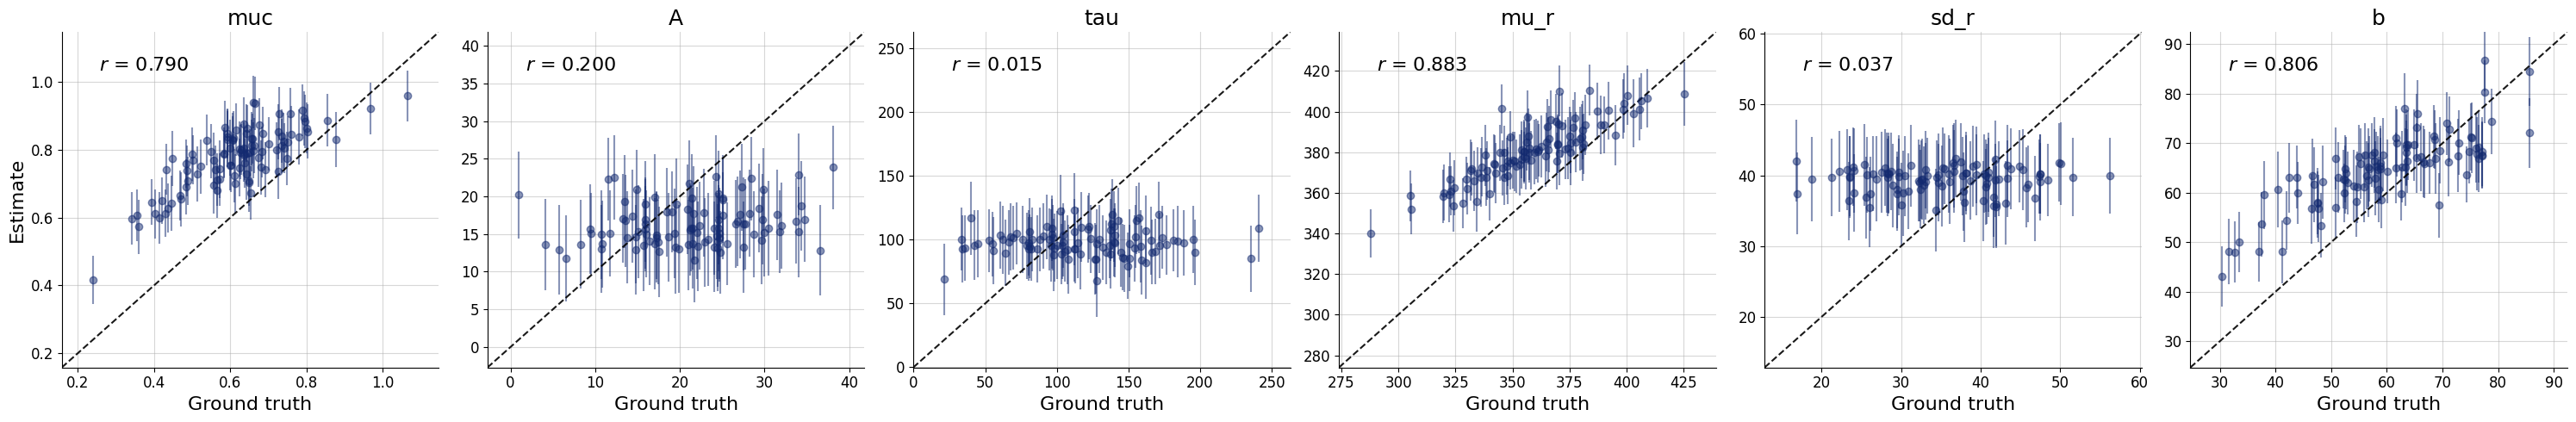

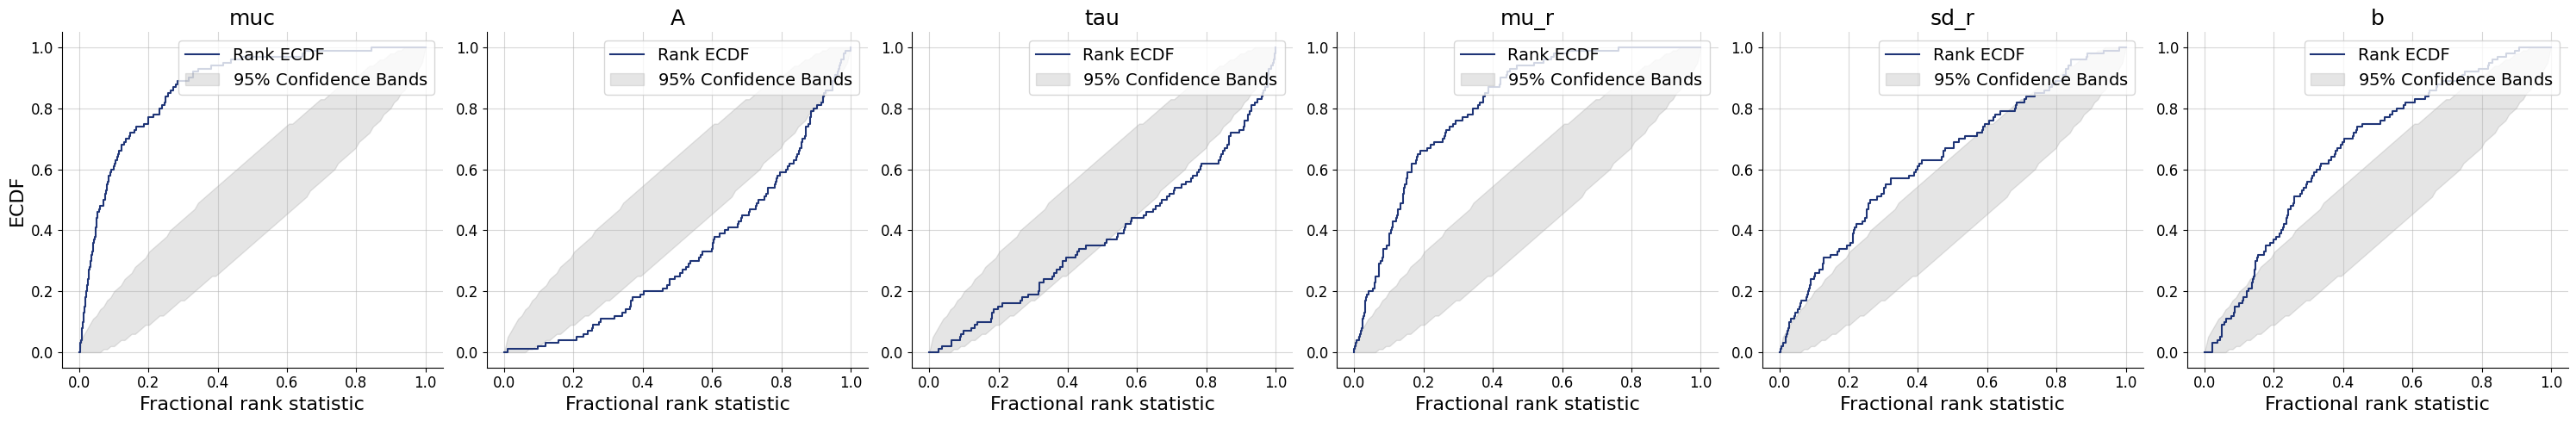

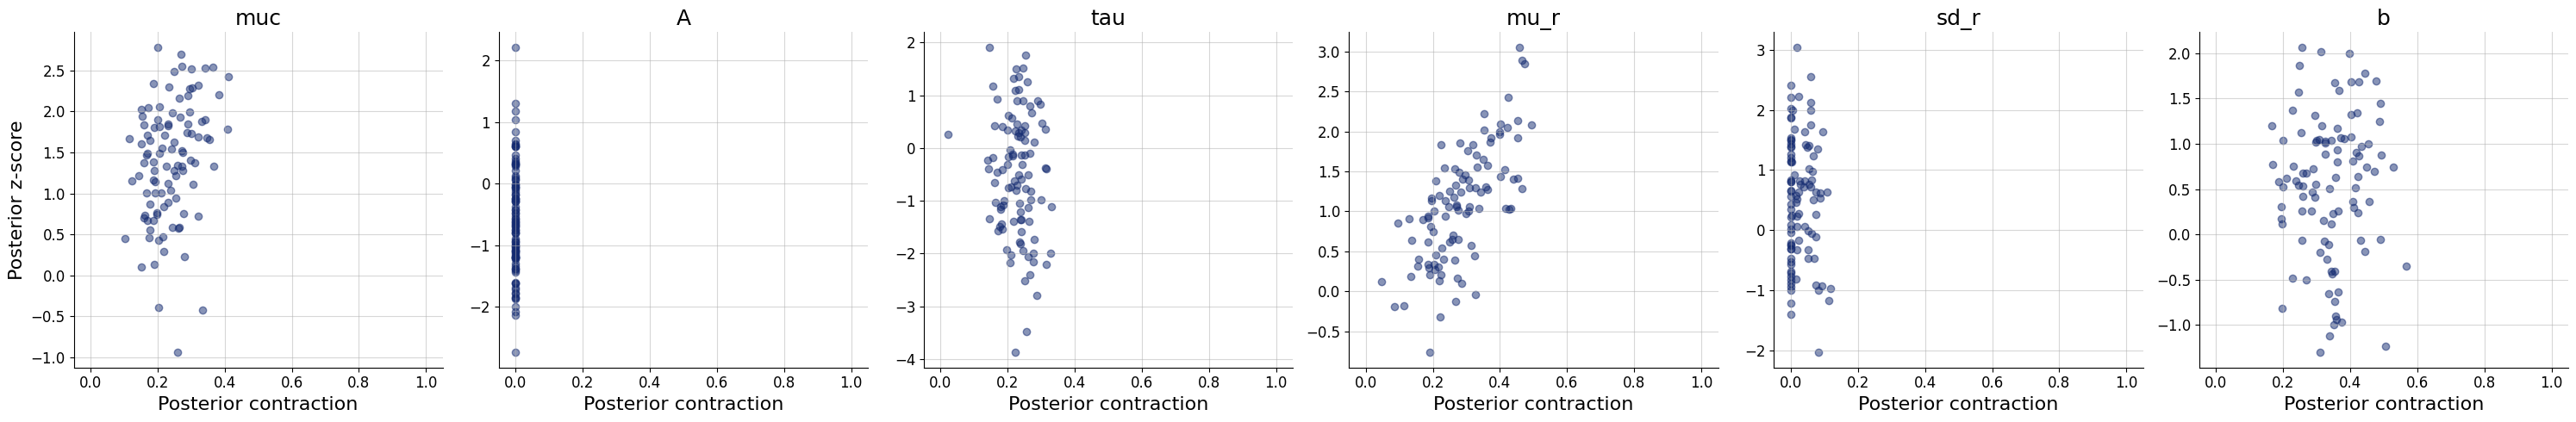

In [77]:
test_data = simulator.sample(100)
plots=workflow.plot_default_diagnostics(test_data=test_data)